# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("loan_data.csv")

# Preview
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


## Analysis of Features Influencing Loan Approval

Based on the visualizations, several quantitative features show a strong relationship with loan approval.

The credit score appears to be one of the most important factors. The boxplot shows that approved applicants tend to have higher credit scores than rejected applicants, indicating that creditworthiness plays a significant role in the model’s decisions.

The person_income feature also demonstrates a clear pattern. Applicants with higher incomes are more likely to be approved, suggesting that financial stability is a key consideration.

Another important variable is loan_percent_income. The visualization shows that approved applicants typically request loans that represent a smaller percentage of their income, while rejected applicants tend to have higher loan-to-income ratios. This suggests that the model strongly favors applicants with lower financial burden relative to their income.

Additionally, credit history length shows some influence. Approved applicants generally have longer credit histories, although the difference is less pronounced compared to credit score and income.

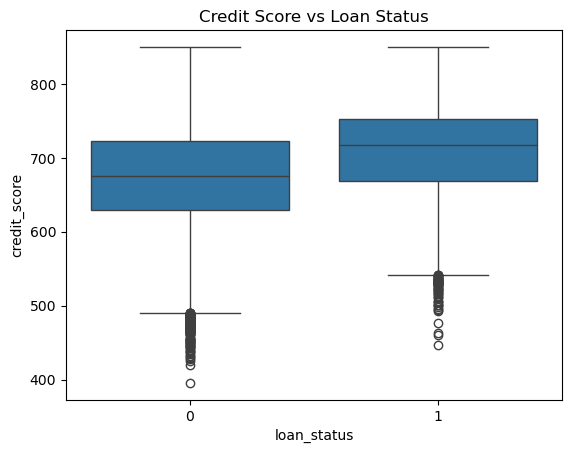

In [5]:
sns.boxplot(x="loan_status", y="credit_score", data=df)
plt.title("Credit Score vs Loan Status")
plt.show()

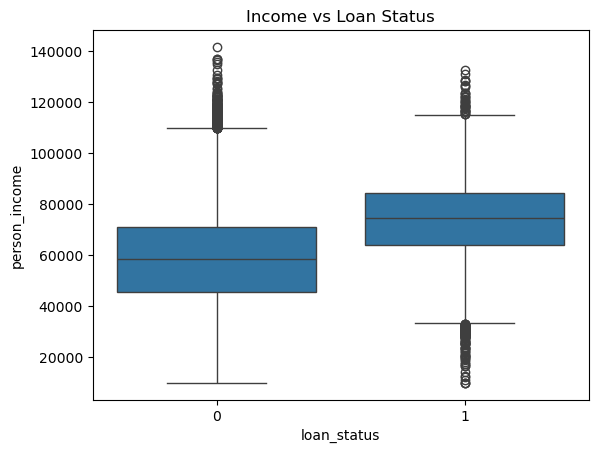

In [4]:
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title("Income vs Loan Status")
plt.show()

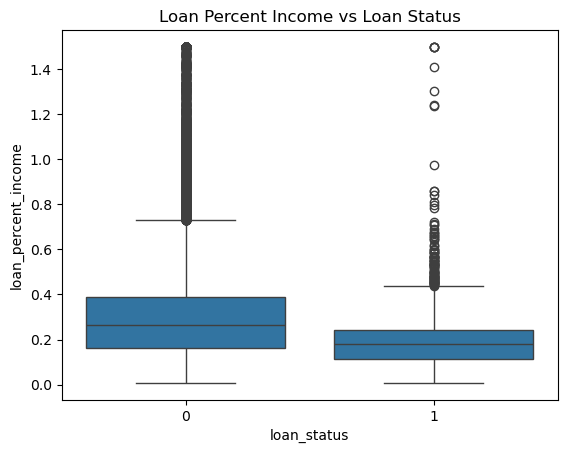

In [8]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title("Loan Percent Income vs Loan Status")
plt.show()

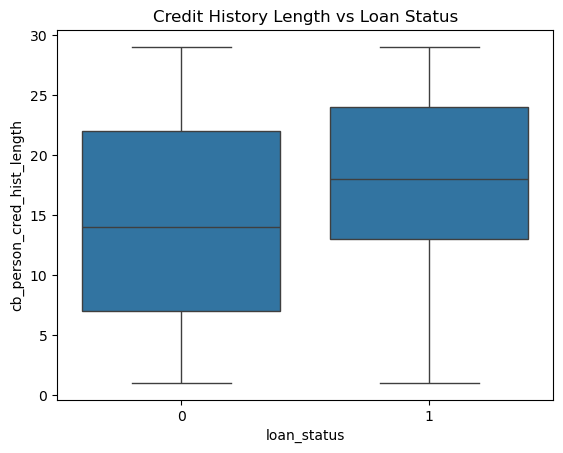

In [9]:
sns.boxplot(x="loan_status", y="cb_person_cred_hist_length", data=df)
plt.title("Credit History Length vs Loan Status")
plt.show()

## Features That Appear Less Related

The loan amount does not show a strong distinction between approved and rejected applicants. The distributions overlap considerably, suggesting that loan amount alone is not a primary factor in determining approval.

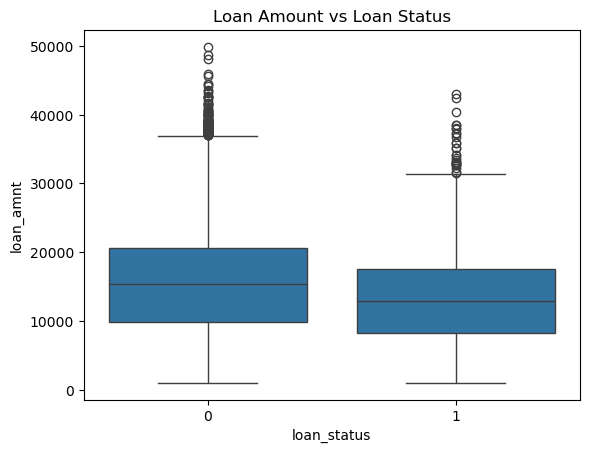

In [7]:
sns.boxplot(x="loan_status", y="loan_amnt", data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

## Analysis of Age and Gender (Potential Bias)

The boxplot for person_age shows similar distributions for both approved and rejected applicants. There is no significant difference in median or spread, indicating that age does not appear to strongly influence the model’s decisions.

The countplot for person_gender shows that approval rates are nearly identical for males and females. Both groups have similar proportions of approved and rejected applications, suggesting that gender is not a significant factor in the model.

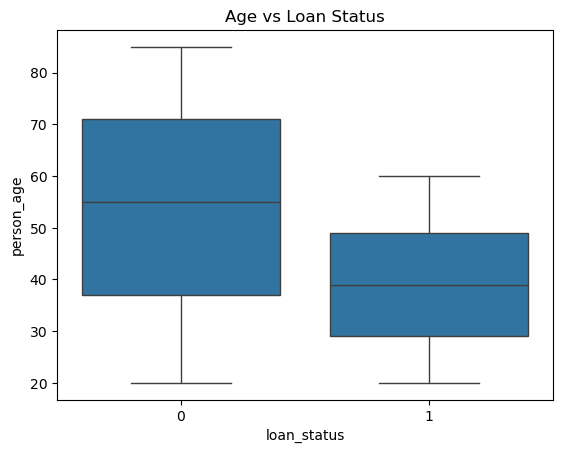

In [2]:
sns.boxplot(x="loan_status", y="person_age", data=df)
plt.title("Age vs Loan Status")
plt.show()

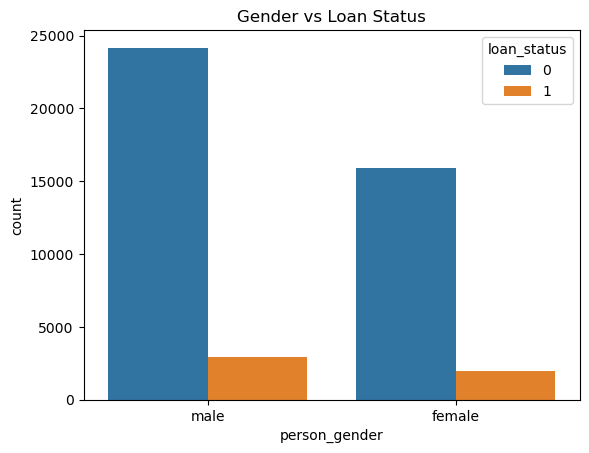

In [3]:
sns.countplot(x="person_gender", hue="loan_status", data=df)
plt.title("Gender vs Loan Status")
plt.show()

## Conclusion: Legal Risk Assessment

Based on the visual evidence, the model appears to rely primarily on financial indicators such as credit score, income, and loan burden rather than protected characteristics like age and gender.

Therefore, the financial institution likely has a low risk of legal issues related to discrimination. However, it would still be advisable to continue monitoring the model to ensure fairness and compliance with applicable regulations.